# PCA Backtest on Polymarket Crypto Belief Panels

This notebook builds and backtests PCA compression on the validated Polymarket crypto panels. It does **not** implement persistent homology, logistic regression, neural nets, or any downstream forecasting model.

The backtest is chronological to avoid overfitting: each fold fits the imputer, standardizer, and PCA only on past data, then evaluates reconstruction on future held-out rows.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "data" / "processed"

core_panel = pd.read_parquet(PROCESSED / "panel_hourly_core.parquet")
core_plus_panel = pd.read_parquet(PROCESSED / "panel_hourly_core_plus_satellites.parquet")
market_universe = pd.read_parquet(PROCESSED / "market_universe.parquet")
validation = json.loads((PROCESSED / "validation_report.json").read_text())

for panel in [core_panel, core_plus_panel]:
    panel.index = pd.to_datetime(panel.index, utc=True)
    panel.columns = panel.columns.astype(str)
market_universe["market_id"] = market_universe["market_id"].astype(str)

print("analysis_ready:", validation["analysis_ready"])
print("core panel:", core_panel.shape, core_panel.index.min(), "to", core_panel.index.max())
print("core+satellite panel:", core_plus_panel.shape, core_plus_panel.index.min(), "to", core_plus_panel.index.max())

analysis_ready: True
core panel: (5696, 21) 2024-12-30 23:00:00+00:00 to 2026-01-01 08:00:00+00:00
core+satellite panel: (5696, 30) 2024-12-30 23:00:00+00:00 to 2026-01-01 08:00:00+00:00


## Modeling Protocol

PCA is evaluated as a compression model. For each chronological fold:

1. Fit a `SimpleImputer` on the training panel only.
2. Fit a `StandardScaler` on the imputed training panel only.
3. Fit PCA on the standardized training panel only.
4. Choose component counts using training explained variance thresholds: 85%, 90%, and 95%.
5. Project the future test panel into PCA space and reconstruct back to probability space.
6. Score only cells that were observed in the original held-out test panel.

Baselines:

- `train_mean`: reconstruct each market using its training mean.
- `last_train_state`: reconstruct each market using the most recent imputed training state.

This avoids leakage from future data into scaling, imputation, or component selection.

In [2]:
def make_folds(panel, initial_train_fraction=0.60, test_window_hours=24*14, step_hours=24*14):
    n = len(panel)
    initial_train = int(n * initial_train_fraction)
    folds = []
    start = initial_train
    while start < n:
        stop = min(start + test_window_hours, n)
        if stop - start >= 24 * 7:
            folds.append((0, start, start, stop))
        start += step_hours
    return folds


def choose_k_from_variance(train_scaled, thresholds):
    full = PCA(n_components=None, svd_solver="full")
    full.fit(train_scaled)
    cumulative = np.cumsum(full.explained_variance_ratio_)
    choices = {f"var_{int(t*100)}": int(np.searchsorted(cumulative, t) + 1) for t in thresholds}
    return choices, cumulative, full


def reconstruct_with_pca(train_df, test_df, n_components):
    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()

    X_train_imp = imputer.fit_transform(train_df)
    X_train_scaled = scaler.fit_transform(X_train_imp)

    pca = PCA(n_components=n_components, svd_solver="full")
    pca.fit(X_train_scaled)

    X_test_imp = imputer.transform(test_df)
    X_test_scaled = scaler.transform(X_test_imp)
    X_test_recon_scaled = pca.inverse_transform(pca.transform(X_test_scaled))
    X_test_recon = scaler.inverse_transform(X_test_recon_scaled)
    X_test_recon = np.clip(X_test_recon, 0, 1)
    return X_test_recon, pca, imputer, scaler


def score_reconstruction(test_df, reconstructed):
    mask = test_df.notna().to_numpy()
    truth = test_df.to_numpy(dtype=float)
    err = reconstructed[mask] - truth[mask]
    return {
        "observed_cells": int(mask.sum()),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "mae": float(np.mean(np.abs(err))),
        "bias": float(np.mean(err)),
    }


def baseline_scores(train_df, test_df):
    imputer = SimpleImputer(strategy="mean")
    X_train_imp = imputer.fit_transform(train_df)
    X_test_shape = test_df.shape
    train_mean = np.tile(imputer.statistics_, (X_test_shape[0], 1))
    last_train_state = np.tile(X_train_imp[-1], (X_test_shape[0], 1))
    return {
        "train_mean": score_reconstruction(test_df, train_mean),
        "last_train_state": score_reconstruction(test_df, last_train_state),
    }


def run_backtest(panel, panel_name, thresholds=(0.85, 0.90, 0.95), fixed_components=(2, 5, 10)):
    panel = panel.sort_index()
    folds = make_folds(panel)
    records = []
    fold_choices = []
    for fold_id, (train_start, train_end, test_start, test_end) in enumerate(folds, start=1):
        train_df = panel.iloc[train_start:train_end]
        test_df = panel.iloc[test_start:test_end]
        imputer = SimpleImputer(strategy="mean")
        scaler = StandardScaler()
        train_scaled = scaler.fit_transform(imputer.fit_transform(train_df))
        var_choices, cumulative, _ = choose_k_from_variance(train_scaled, thresholds)
        k_map = {**var_choices}
        for k in fixed_components:
            if k <= panel.shape[1]:
                k_map[f"fixed_{k}"] = k
        fold_choices.append({"fold": fold_id, **var_choices})
        for baseline_name, metrics in baseline_scores(train_df, test_df).items():
            records.append({
                "panel": panel_name,
                "fold": fold_id,
                "model": baseline_name,
                "n_components": 0,
                "compression_ratio": 0.0,
                "train_start": str(train_df.index.min()),
                "train_end": str(train_df.index.max()),
                "test_start": str(test_df.index.min()),
                "test_end": str(test_df.index.max()),
                **metrics,
            })
        for model_name, k in sorted(k_map.items(), key=lambda item: (item[1], item[0])):
            reconstructed, pca, _, _ = reconstruct_with_pca(train_df, test_df, k)
            metrics = score_reconstruction(test_df, reconstructed)
            records.append({
                "panel": panel_name,
                "fold": fold_id,
                "model": model_name,
                "n_components": k,
                "compression_ratio": k / panel.shape[1],
                "train_start": str(train_df.index.min()),
                "train_end": str(train_df.index.max()),
                "test_start": str(test_df.index.min()),
                "test_end": str(test_df.index.max()),
                **metrics,
            })
    return pd.DataFrame(records), pd.DataFrame(fold_choices)

core_results, core_choices = run_backtest(core_panel, "core")
core_plus_results, core_plus_choices = run_backtest(core_plus_panel, "core_plus_satellites")
results = pd.concat([core_results, core_plus_results], ignore_index=True)
results.to_csv(PROCESSED / "pca_backtest_results.csv", index=False)
display(results.head())
print("Backtest rows:", len(results))

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: divide by

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: divide by

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: divide by

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: divide by

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: divide by

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: divide by

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: divide by

,panel,fold,model,n_components,compression_ratio,train_start,train_end,test_start,test_end,observed_cells,rmse,mae,bias
0,core,1,train_mean,0,0.000000,2024-12-30 23:00:00+00:00,2025-09-28 09:00:00+00:00,2025-09-28 10:00:00+00:00,2025-10-12 09:00:00+00:00,5712,0.121648,0.082114,0.037743
1,core,1,last_train_state,0,0.000000,2024-12-30 23:00:00+00:00,2025-09-28 09:00:00+00:00,2025-09-28 10:00:00+00:00,2025-10-12 09:00:00+00:00,5712,0.099410,0.053262,-0.046758
2,core,1,fixed_2,2,0.095238,2024-12-30 23:00:00+00:00,2025-09-28 09:00:00+00:00,2025-09-28 10:00:00+00:00,2025-10-12 09:00:00+00:00,5712,0.048216,0.030615,0.005141
3,core,1,var_85,4,0.190476,2024-12-30 23:00:00+00:00,2025-09-28 09:00:00+00:00,2025-09-28 10:00:00+00:00,2025-10-12 09:00:00+00:00,5712,0.037728,0.023470,0.001687
4,core,1,fixed_5,5,0.238095,2024-12-30 23:00:00+00:00,2025-09-28 09:00:00+00:00,2025-09-28 10:00:00+00:00,2025-10-12 09:00:00+00:00,5712,0.037505,0.022972,0.002960


Backtest rows: 112


## Data Coverage Used by PCA

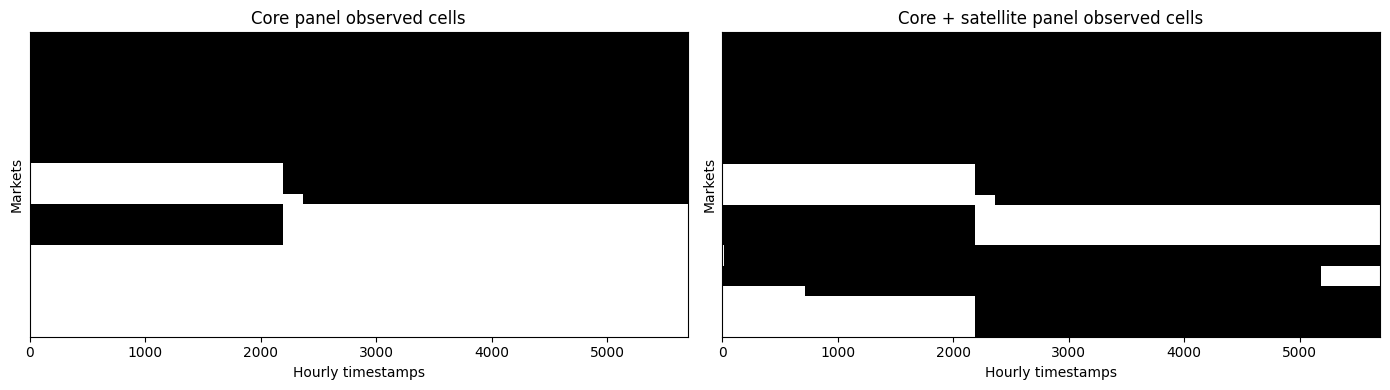

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, panel, title in [
    (axes[0], core_panel, "Core panel observed cells"),
    (axes[1], core_plus_panel, "Core + satellite panel observed cells"),
]:
    ax.imshow(panel.notna().T, aspect="auto", interpolation="nearest", cmap="Greys")
    ax.set_title(title)
    ax.set_xlabel("Hourly timestamps")
    ax.set_ylabel("Markets")
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## Explained Variance on the Initial Training Window

Components chosen on first training window: {'var_85': 4, 'var_90': 5, 'var_95': 7}


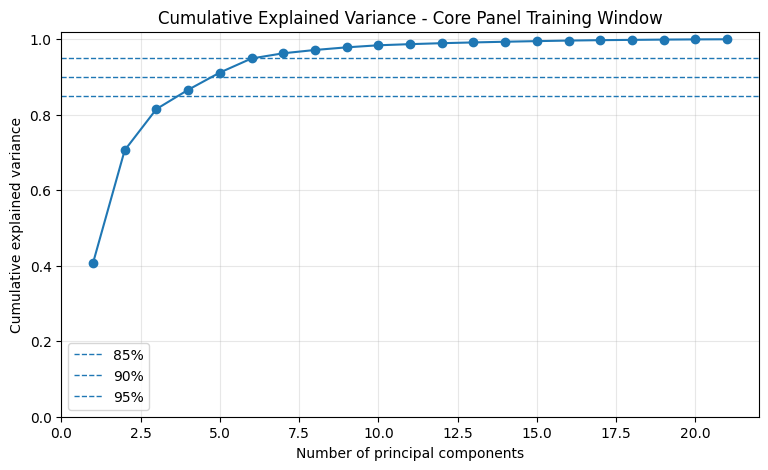

In [4]:
initial_train_end = int(len(core_panel) * 0.60)
train_core = core_panel.iloc[:initial_train_end]
imputer = SimpleImputer(strategy="mean")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(imputer.fit_transform(train_core))
var_choices, cumulative, full_pca = choose_k_from_variance(X_train_scaled, [0.85, 0.90, 0.95])
explained = full_pca.explained_variance_ratio_

print("Components chosen on first training window:", var_choices)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(cumulative) + 1), cumulative, marker="o")
for threshold in [0.85, 0.90, 0.95]:
    ax.axhline(threshold, linestyle="--", linewidth=1, label=f"{int(threshold*100)}%")
ax.set_title("Cumulative Explained Variance - Core Panel Training Window")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance")
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## PCA Projection: First Two Components

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


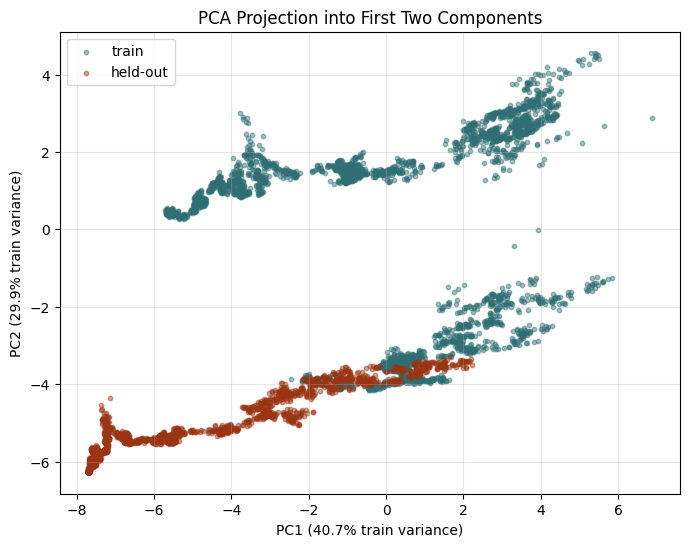

In [5]:
split = int(len(core_panel) * 0.60)
train_df = core_panel.iloc[:split]
test_df = core_panel.iloc[split:]
imputer = SimpleImputer(strategy="mean")
scaler = StandardScaler()
X_train = scaler.fit_transform(imputer.fit_transform(train_df))
X_test = scaler.transform(imputer.transform(test_df))
pca2 = PCA(n_components=2, svd_solver="full")
Z_train = pca2.fit_transform(X_train)
Z_test = pca2.transform(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(Z_train[:, 0], Z_train[:, 1], s=10, alpha=0.45, label="train", color="#2f6f73")
ax.scatter(Z_test[:, 0], Z_test[:, 1], s=10, alpha=0.45, label="held-out", color="#9a3412")
ax.set_title("PCA Projection into First Two Components")
ax.set_xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% train variance)")
ax.set_ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% train variance)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Backtest Reconstruction Performance

In [6]:
summary = (
    results.groupby(["panel", "model"], as_index=False)
    .agg(
        folds=("fold", "nunique"),
        min_components=("n_components", "min"),
        median_components=("n_components", "median"),
        max_components=("n_components", "max"),
        mean_compression_ratio=("compression_ratio", "mean"),
        mean_rmse=("rmse", "mean"),
        median_rmse=("rmse", "median"),
        mean_mae=("mae", "mean"),
        mean_bias=("bias", "mean"),
        observed_cells=("observed_cells", "sum"),
    )
    .sort_values(["panel", "mean_rmse"])
)
display(summary)

,panel,model,folds,min_components,median_components,max_components,mean_compression_ratio,mean_rmse,median_rmse,mean_mae,mean_bias,observed_cells
0,core,fixed_10,7,10,10.0,10,0.476190,0.013682,0.012712,0.007466,0.001130,38743
7,core,var_95,7,5,6.0,7,0.292517,0.026358,0.023673,0.014609,0.005800,38743
2,core,fixed_5,7,5,5.0,5,0.238095,0.030252,0.029205,0.016965,0.008390,38743
6,core,var_90,7,4,5.0,5,0.217687,0.031047,0.033662,0.017330,0.008781,38743
5,core,var_85,7,3,4.0,4,0.170068,0.032451,0.033952,0.018235,0.009326,38743
3,core,last_train_state,7,0,0.0,0,0.000000,0.041780,0.036460,0.022325,0.002725,38743
1,core,fixed_2,7,2,2.0,2,0.095238,0.052838,0.048357,0.032705,0.024808,38743
4,core,train_mean,7,0,0.0,0,0.000000,0.177640,0.204313,0.136972,0.130245,38743
8,core_plus_satellites,fixed_10,7,10,10.0,10,0.333333,0.026090,0.026228,0.012779,0.005739,58228
15,core_plus_satellites,var_95,7,8,10.0,10,0.314286,0.026115,0.026228,0.012818,0.005777,58228


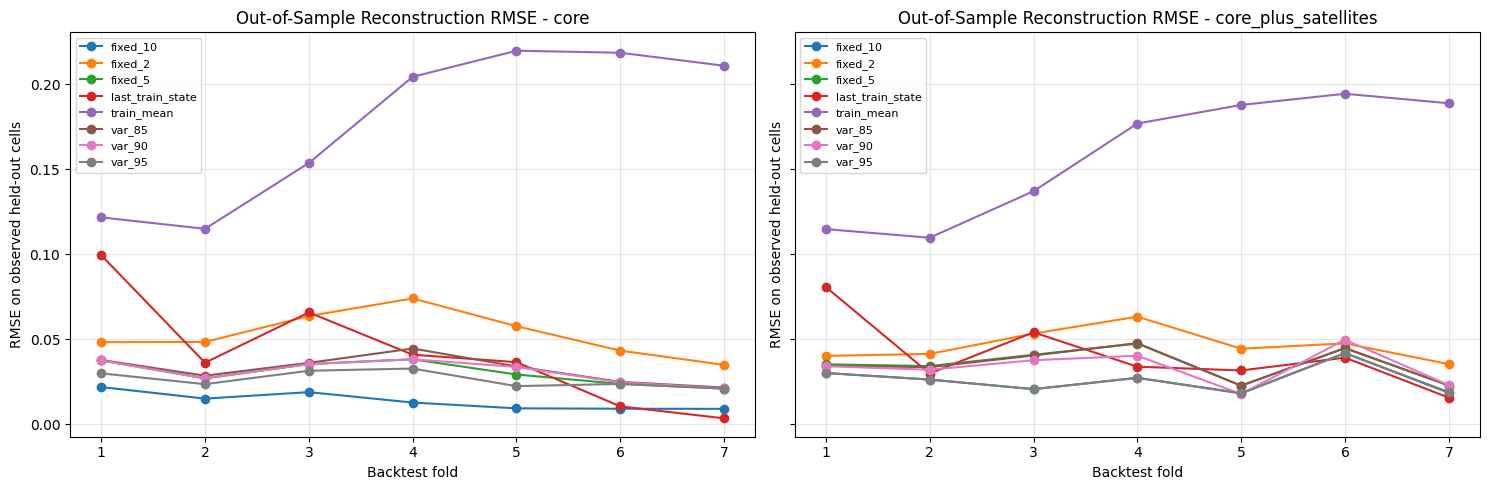

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, panel_name in zip(axes, ["core", "core_plus_satellites"]):
    sub = results[results["panel"] == panel_name]
    for model, g in sub.groupby("model"):
        ax.plot(g["fold"], g["rmse"], marker="o", linewidth=1.5, label=model)
    ax.set_title(f"Out-of-Sample Reconstruction RMSE - {panel_name}")
    ax.set_xlabel("Backtest fold")
    ax.set_ylabel("RMSE on observed held-out cells")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Component Loadings

,PC1,question,market_family,asset,threshold,direction
market_id,,,,,,
516876,0.326815,"Will Ethereum hit $7,000 by December 31?",eth_price,ETH,7.000000e+12,above
516865,0.322736,"Will Bitcoin reach $130,000 by December 31, 2025?",btc_price,BTC,1.300000e+14,above
516875,0.317640,"Will Ethereum hit $8,000 by December 31?",eth_price,ETH,8.000000e+12,above
516877,0.313779,"Will Ethereum hit $6,000 by December 31?",eth_price,ETH,6.000000e+12,above
515505,0.298972,"Will Bitcoin reach $120,000 by March 31?",btc_price,BTC,1.200000e+14,above
515502,0.295227,"Will Bitcoin reach $200,000 by March 31?",btc_price,BTC,2.000000e+14,above
515503,0.295008,"Will Bitcoin reach $150,000 by March 31?",btc_price,BTC,1.500000e+14,above
516874,0.280515,"Will Ethereum hit $10,000 by December 31?",eth_price,ETH,1.000000e+13,above
516878,0.268704,"Will Ethereum hit $5,000 by December 31?",eth_price,ETH,5.000000e+12,above


,PC2,question,market_family,asset,threshold,direction
market_id,,,,,,
516862,0.389692,"Will Bitcoin reach $250,000 by December 31, 2025?",btc_price,BTC,2.500000e+14,above
516863,0.381940,"Will Bitcoin reach $200,000 by December 31, 2025?",btc_price,BTC,2.000000e+14,above
516861,0.380224,"Will Bitcoin reach $1,000,000 by December 31, ...",btc_price,BTC,1.000000e+15,above
516873,0.350578,"Will Bitcoin dip to $20,000 by December 31, 2025?",btc_price,BTC,2.000000e+13,below
516871,0.336808,"Will Bitcoin dip to $70,000 by December 31, 2025?",btc_price,BTC,7.000000e+13,below
516872,0.316414,"Will Bitcoin dip to $50,000 by December 31, 2025?",btc_price,BTC,5.000000e+13,below
516864,0.265128,"Will Bitcoin reach $150,000 by December 31, 2025?",btc_price,BTC,1.500000e+14,above
516878,-0.237803,"Will Ethereum hit $5,000 by December 31?",eth_price,ETH,5.000000e+12,above
516874,0.175521,"Will Ethereum hit $10,000 by December 31?",eth_price,ETH,1.000000e+13,above


,PC3,question,market_family,asset,threshold,direction
market_id,,,,,,
574073,0.580391,"Will Bitcoin reach $170,000 by December 31, 2025?",btc_price,BTC,1.700000e+14,above
574072,0.526463,"Will Bitcoin reach $140,000 by December 31, 2025?",btc_price,BTC,1.400000e+14,above
574071,0.365632,"Will Ethereum hit $14,000 by December 31?",eth_price,ETH,1.400000e+13,above
515503,-0.234033,"Will Bitcoin reach $150,000 by March 31?",btc_price,BTC,1.500000e+14,above
515502,-0.233271,"Will Bitcoin reach $200,000 by March 31?",btc_price,BTC,2.000000e+14,above
515505,-0.220884,"Will Bitcoin reach $120,000 by March 31?",btc_price,BTC,1.200000e+14,above
576410,0.212883,"Will Ethereum hit $17,000 by December 31?",eth_price,ETH,1.700000e+13,above
515557,-0.134310,"Will Bitcoin dip to $70,000 by March 31?",btc_price,BTC,7.000000e+13,below
516875,0.080454,"Will Ethereum hit $8,000 by December 31?",eth_price,ETH,8.000000e+12,above


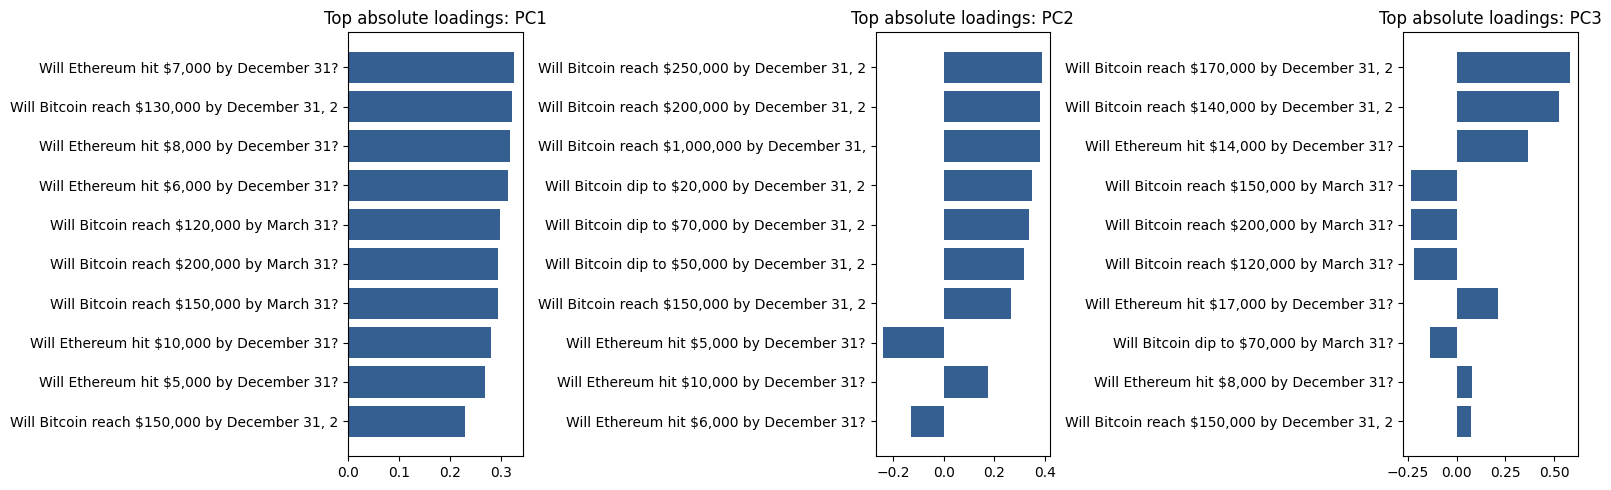

In [8]:
meta_cols = ["market_id", "question", "market_family", "asset", "threshold", "direction", "target_date"]
meta = market_universe[[c for c in meta_cols if c in market_universe.columns]].set_index("market_id")
loading_df = pd.DataFrame(
    full_pca.components_[:3].T,
    index=train_core.columns.astype(str),
    columns=["PC1", "PC2", "PC3"],
).join(meta, how="left")

for pc in ["PC1", "PC2", "PC3"]:
    top = loading_df.reindex(loading_df[pc].abs().sort_values(ascending=False).head(10).index)
    display(top[[pc, "question", "market_family", "asset", "threshold", "direction"]])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, pc in zip(axes, ["PC1", "PC2", "PC3"]):
    top = loading_df.reindex(loading_df[pc].abs().sort_values(ascending=False).head(10).index)
    labels = [str(q)[:45] if pd.notna(q) else str(idx)[:45] for idx, q in top["question"].items()]
    ax.barh(labels, top[pc], color="#365f91")
    ax.set_title(f"Top absolute loadings: {pc}")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Example Reconstruction on a Held-Out Fold

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:197: RuntimeWarning: divide by

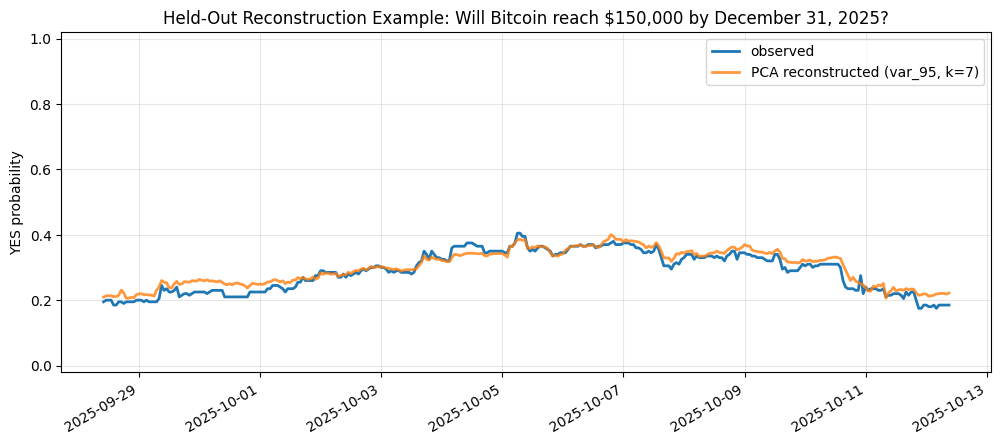

In [9]:
best_row = summary[(summary["panel"] == "core") & (summary["model"].str.startswith("var_"))].sort_values("mean_rmse").iloc[0]
best_model = best_row["model"]
first_fold = results[(results["panel"] == "core") & (results["model"] == best_model)].sort_values("fold").iloc[0]
fold_id = int(first_fold["fold"])
folds = make_folds(core_panel)
_, train_end, test_start, test_end = folds[fold_id - 1]
train_df = core_panel.iloc[:train_end]
test_df = core_panel.iloc[test_start:test_end]

train_scaled = StandardScaler().fit_transform(SimpleImputer(strategy="mean").fit_transform(train_df))
choices, _, _ = choose_k_from_variance(train_scaled, [0.85, 0.90, 0.95])
k = choices[best_model]
reconstructed, _, _, _ = reconstruct_with_pca(train_df, test_df, k)
recon_df = pd.DataFrame(reconstructed, index=test_df.index, columns=test_df.columns)
market_id = test_df.notna().sum().sort_values(ascending=False).index[0]
label = meta.loc[market_id, "question"] if market_id in meta.index else market_id

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_df.index, test_df[market_id], label="observed", linewidth=2)
ax.plot(recon_df.index, recon_df[market_id], label=f"PCA reconstructed ({best_model}, k={k})", linewidth=2, alpha=0.8)
ax.set_title(f"Held-Out Reconstruction Example: {label[:90]}")
ax.set_ylabel("YES probability")
ax.set_ylim(-0.02, 1.02)
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.show()

## Takeaways

- PCA was fit only on past data in each backtest fold.
- Standardization and imputation were also fit only on each training window.
- Component counts chosen by explained variance were selected from training variance only.
- Scores are out-of-sample reconstruction errors on observed held-out cells, not in-sample explained variance.
- This notebook evaluates linear compression quality; it does not claim PCA is a forecasting model by itself.